개방자치코드    int64
인허가일자       str
영업상태코드    int64
상세영업상태      str
소재지         str
도로명         str
사업장명        str
자본금       int64
dtype: object
개방자치코드      0
인허가일자       0
영업상태코드      0
상세영업상태      3
소재지         0
도로명       883
사업장명        0
자본금         0
dtype: int64
3
        개방자치코드       인허가일자  영업상태코드 상세영업상태                                소재지  \
2480   3170000  2010-03-16       1    영업중       서울특별시 금천구 가산동 월드메르디앙1차 1414호   
2481   3170000  2010-03-16       1    영업중       서울특별시 금천구 가산동 월드메르디앙1차 1414호   
5007   3330000  2015-07-02       1    영업중  부산광역시 해운대구 좌동 1427-2 부산좌동 창업지원주택    
5008   3330000  2015-07-02       1    영업중  부산광역시 해운대구 좌동 1427-2 부산좌동 창업지원주택    
16279  6520000  2016-07-21       1    영업중          제주특별자치도 서귀포시 대포동 760-3번지    
16280  6520000  2016-07-21       1    영업중          제주특별자치도 서귀포시 대포동 760-3번지    

                                                    도로명       사업장명       자본금  
2480           서울특별시 금천구 벚꽃로 254, 1414호 (가산동, 월드메르디앙1차)  아이빛연구소(주)  34591000  
2481        

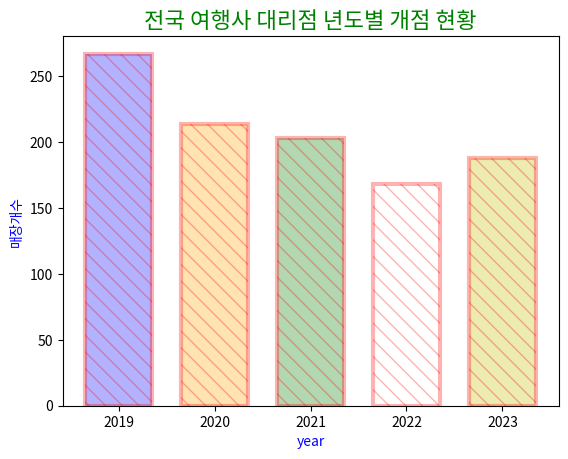

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1번 제제
df = pd.read_csv("./data/travel.csv")
# 2번 문제
print(df.dtypes)
# 3번 문제
print(df.isnull().sum())
# 4-1 문제
print(df.duplicated().sum())
# 4-2 문제
print(df[df.duplicated(keep=False)])
#5번 문제
df.dropna(subset=['상세영업상태','도로명'],inplace=True)
print(df.isnull().sum())
# 6번 문제
df.drop_duplicates(keep='first', inplace=True)
# 7번 문제
df.drop('도로명',axis=1,inplace=True)
print(df.dtypes)
# 8번 문제
print(df['자본금'].describe().round(5))
# 9번 문제 
df = df[df['상세영업상태'] == '영업중']
print(df['상세영업상태'].unique()) # 상세영업상태의 값 조회 - '영업중'만 나오는지 확인
# 10번 문제
df.loc[df['자본금'] < 30000000, '자본금'] = 32000000
# 11-1번 문제 
df['인허가일자'] = pd.to_datetime(df['인허가일자'])
# 11-2번 문제
df['개점년도'] = df['인허가일자'].dt.year
# 12번 문제
cnt = df.groupby('개점년도')['사업장명'].nunique()
year_sum = df.groupby('개점년도')['자본금'].sum()
new_df = pd.DataFrame({'사업장명' : cnt, '자본금' : year_sum})
# 13번 문제
new_df.rename(columns={'사업장명' :'년도별매장개수'}, inplace=True)
# 14번 문제
new_df['순위'] = new_df['년도별매장개수'].rank(method='first', ascending=False).astype(int)
new_df = new_df.sort_values(by='년도별매장개수',ascending=False)
# 15번 문제
branch_rank = new_df.loc[(new_df.index > 2018) & (new_df.index <= 2023),['년도별매장개수', '자본금', '순위']]
# 16번 문제 
plt.rcParams["font.family"] = 'malgun gothic'
colors = ['b','orange','g','y','white']
plt.bar(branch_rank.index,branch_rank['년도별매장개수'],
        color=colors, width=0.7, edgecolor='r', linewidth=3, alpha=0.3, hatch='\\\\')
plt.title('전국 여행사 대리점 년도별 개점 현황',fontsize=16, color = 'g')
plt.xlabel('year',color = 'b')
plt.ylabel('매장개수', color = 'b')
# 17번 문제 
fig = plt.gcf()
plt.draw()
fig.savefig("./images/travel.png",dpi = fig.dpi)